# Spending Beyond our K-Means

The previous example included four customer segments. In this activity, you’ll cluster the data into five customer segments. You’ll decide whether going from four to five segments reveals any relevant differences in consumer spending habits.

Instructions

1. Read in the `shopping_data.csv` file from the Resources folder and create the DataFrame. Review the resulting DataFrame. Additionally, check the data types associated with the DataFrame.

2. Build a helper function called `encodeCard` that sets the `card_type` variable to 1 for credit card purchases and 0 for debit card purchases. 

3. Edit the `Card Type` column in the DataFrame by applying the `encodeCard` function. 

4. Scale the `Annual Income` column in the DataFrame by dividing it by 1,000. 

5. Drop the `CustomerID` column from the DataFrame. 

6. Review the `df_shopping` DataFrame. Confirm that the `Card Type` column consists of 1s and 0s; that the Annual_Income column is scaled appropriately; and that the `CustomerID` column has been dropped. 

7. Using this cleaned DataFrame, initialize two K-means models: one with four clusters and another with five. For each model, be sure to follow each of the steps needed to identify the clusters and assign them to the data. 

* Initialize the KMeans model instance.
* Fit, or train, the model.
* Predict the model segments(clusters).

8. Once the models have been run, create a copy of the `df_shopping` DataFrame and name it as `df_shopping_predictions`. Next, add each of the customer segments into the `df_shopping_predictions` DataFrame as new columns. 

9. Using hvPlot, create scatter plots for each of the two customer segmentsations. Be sure to build styled and formatted plots.

10. Answer the following question:  Do you note any relevant differences between the two Kmeans models?



References

[scikit-learn Python Library](https://scikit-learn.org)

[scikit-learn ML Algorithms](https://scikit-learn.org/stable/user_guide.html)

[scikit-learn K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)




In [2]:
# Import the required libraries and dependencies
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Step 1: Read in the `shopping_data.csv` file from the Resources folder and create the DataFrame. Review the resulting DataFrame. Additionally, check the data types associated with the DataFrame.

In [13]:
# Read in the CSV file and create the Pandas DataFrame
df_shopping = pd.read_csv(
    Path("10.2/01-Spending_Beyond_Our_Kmeans/Resources/shopping_data.csv")
)

# Review the DataFrame
df_shopping.head()

,CustomerID,Card Type,Age,Annual Income,Spending Score
0,1,Credit,19,15000,39
1,2,Credit,21,15000,81
2,3,Debit,20,16000,6
3,4,Debit,23,16000,77
4,5,Debit,31,17000,40


In [5]:
# Check the DataFrame data types
df_shopping.dtypes

CustomerID         int64
Card Type         object
Age                int64
Annual Income      int64
Spending Score     int64
dtype: object

## Step 2: Build a helper function called `encodeCard` that sets the `card_type` variable to 1 for credit card purchases and 0 for debit card purchases. 

In [15]:
# Build the encodeCard helper function
# Credit card purchases should encode to 1
# Debit card purchases should encode to 0

def encodeCard(card_type):
    if card_type.lower() == 'credit':
        return 1
    else:
        return 0


## Step 3: Edit the `Card Type` column in the DataFrame by applying the `encodeCard` function. 

In [16]:
# Edit the `Card Type` column using the encodeCard function
df_shopping['Card Type'] = df_shopping['Card Type'].apply(encodeCard)

df_shopping.head()


,Card Type,Age,Annual Income,Spending Score
0,1,19,15000,39
1,1,21,15000,81
2,0,20,16000,6
3,0,23,16000,77
4,0,31,17000,40


## Step 4: Scale the `Annual Income` column in the DataFrame by dividing it by 1,000. 

In [17]:
# Scale the Annual Income column 
df_shopping['Annual Income'] = df_shopping['Annual Income'] / 1000

df_shopping.head()

,Card Type,Age,Annual Income,Spending Score
0,1,19,15.0,39
1,1,21,15.0,81
2,0,20,16.0,6
3,0,23,16.0,77
4,0,31,17.0,40


## Step 5: Drop the `CustomerID` column from the DataFrame. 

In [14]:
# Drop the CustomerID column
df_shopping = df_shopping.drop(columns = ['CustomerID'])


,Card Type,Age,Annual Income,Spending Score
0,Credit,19,15000,39
1,Credit,21,15000,81
2,Debit,20,16000,6
3,Debit,23,16000,77
4,Debit,31,17000,40


## Step 6: Review the `df_shopping` DataFrame. Confirm that the `Card Type` column consists of 1s and 0s; that the Annual_Income column is scaled appropriately; and that the `CustomerID` column has been dropped. 

In [18]:
# Review the DataFrame
display(df_shopping.head())
display(df_shopping.tail())

,Card Type,Age,Annual Income,Spending Score
0,1,19,15.0,39
1,1,21,15.0,81
2,0,20,16.0,6
3,0,23,16.0,77
4,0,31,17.0,40


,Card Type,Age,Annual Income,Spending Score
195,0,35,120.0,79
196,0,45,126.0,28
197,1,32,126.0,74
198,1,32,137.0,18
199,1,30,137.0,83


## Step 7: Using this cleaned DataFrame, initialize two K-means models: one with four clusters and another with five. For each model, be sure to follow each of the steps needed to identify the clusters and assign them to the data. 

* Initialize the KMeans model instance.
* Fit, or train, the model.
* Predict the model segments(clusters).

### Train the K-means algorithm where k=4

In [19]:
# Initialize the K-Means model; n_clusters=4
model_k4 = KMeans(n_clusters=4)


In [20]:
# Fit the model
model_k4.fit(df_shopping)

KMeans(n_clusters=4)

In [21]:
# Predict the model segments (clusters)
customer_segments_k4 = model_k4.predict(df_shopping)

print(customer_segments_k4)

[3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3
 0 3 0 3 0 3 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


### Train the K-means algorithm where k=5

In [22]:
# Initialize the K-Means model; n_clusters=5
model_k5 = KMeans(n_clusters=5)

In [23]:
# Fit the model
model_k5.fit(df_shopping)

KMeans(n_clusters=5)

In [24]:
# Predict the model segments (clusters)
customer_segments_k5 = model_k5.predict(df_shopping)

# View the customer segments
print(customer_segments_k5)

[2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 1 3 2 3 2 3 1 3 3 3 1 3 3 1 1 1 1 1 3 1 1 3 1 1 1 3 1 1 3 3 1 1 1 1
 1 3 1 1 3 1 1 1 1 1 3 1 1 3 3 1 1 3 1 1 1 3 1 3 1 3 3 1 1 3 1 3 1 1 1 1 1
 3 1 3 3 3 1 1 1 1 3 1 1 4 0 4 1 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4]


## Step 8: Once the models hvae been run, add each of the customer segment lists back into the `df_shopping` DataFrame as new columns. 

In [25]:
# Crate a copy of the df_shopping DataFrame and name it as df_shopping_predictions
df_shopping_predictions = df_shopping.copy()

In [26]:
# Create a new column in the DataFrame with the predicted clusters with k=4
df_shopping_predictions["Customer Segment (k=4)"] = customer_segments_k4

In [27]:
# Create a new column in the DataFrame with the predicted clusters with k=5
df_shopping_predictions["Customer Segment (k=5)"] = customer_segments_k5

In [28]:
# Review the DataFrame
df_shopping_predictions.head()

,Card Type,Age,Annual Income,Spending Score,Customer Segment (k=4),Customer Segment (k=5)
0,1,19,15.0,39,3,2
1,1,21,15.0,81,0,3
2,0,20,16.0,6,3,2
3,0,23,16.0,77,0,3
4,0,31,17.0,40,3,2


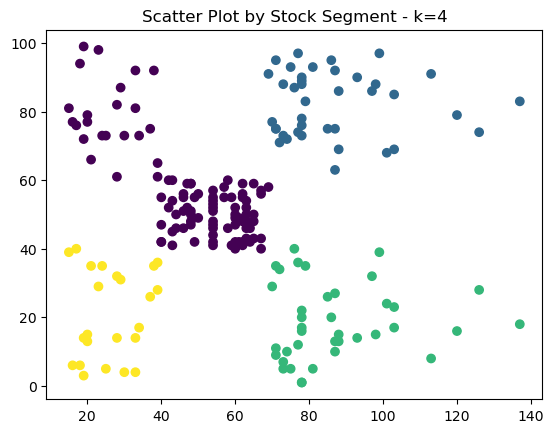

In [32]:
# Create a scatter plot with with x="Annual Income" and y="Spending Score (1-100)" with k=4 segments
plt.title('Scatter Plot by Stock Segment - k=4')
plt.scatter(df_shopping_predictions['Annual Income'], df_shopping_predictions['Spending Score'],c= df_shopping_predictions["Customer Segment (k=4)"])

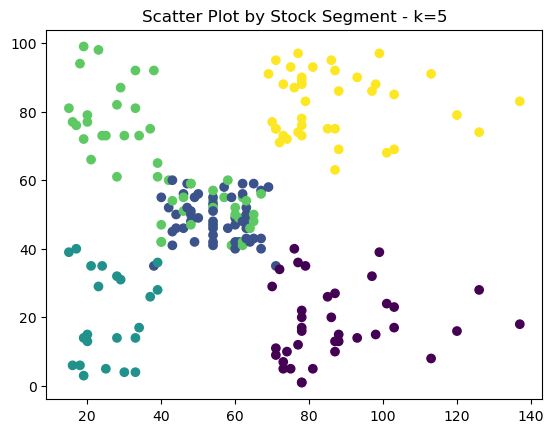

In [33]:
# Create a scatter plot with x="Annual Income" and y="Spending Scoree" with k=5 segments
plt.title('Scatter Plot by Stock Segment - k=5')
plt.scatter(df_shopping_predictions['Annual Income'], df_shopping_predictions['Spending Score'],c= df_shopping_predictions["Customer Segment (k=5)"])

## Step 10: Answer the following question:

**Question**  Do you note any relevant differences between the two Kmeans models?

**Answer** There is a big difference in the cluster assignment for transactions involving individuals with an income of less that 40,000 and a spending score of less than 40. With 5 clusters, these individuals are assinged their own segment. With only 4 clusters, they are assigned to a segment that includes individuals with incomes between 40,000 and 75.000 and a spending score between 40 and 60. 5 clusters seems to fit this dataset much better.